In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


# DATA WRANGLING

In [4]:
dataset = '/content/drive/MyDrive/Colab Notebooks/Bias_dataset.xlsx'
'''with open(dataset, 'r') as f:
        bias_text = f.read()
bias_text'''
bias_text = pd.read_excel(dataset)
bias_text.head()

,Sentences,Type of Bias,Category of Bias
0,Heart problems aren't as serious for younger p...,Implicit,Age
1,Busy professionals should be more cautious abo...,Implicit,Lifestyle
2,It's surprising to see a fit person suffer fro...,Implicit,Lifestyle
3,People with high-stress jobs tend to have weak...,Implicit,Lifestyle
4,A healthy diet is less important for young peo...,Implicit,Age


In [5]:
print(bias_text.info)

<bound method DataFrame.info of                                               Sentences Type of Bias  \
0     Heart problems aren't as serious for younger p...     Implicit   
1     Busy professionals should be more cautious abo...     Implicit   
2     It's surprising to see a fit person suffer fro...     Implicit   
3     People with high-stress jobs tend to have weak...     Implicit   
4     A healthy diet is less important for young peo...     Implicit   
...                                                 ...          ...   
2002          Women tend to be more emotional than men.     Implicit   
2003  People from certain ethnic backgrounds are mor...     Implicit   
2004         People from rural areas are less educated.     Implicit   
2005  Older individuals are slower in grasping new c...     Implicit   
2006  Individuals with a sedentary lifestyle are at ...     Implicit   

     Category of Bias  
0                 Age  
1           Lifestyle  
2           Lifestyle  
3      

In [6]:
print(bias_text.shape)

(2007, 3)


In [7]:
bias_text.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Sentences         2007 non-null   object
 1   Type of Bias      1187 non-null   object
 2   Category of Bias  943 non-null    object
dtypes: object(3)
memory usage: 47.2+ KB


In [8]:
# Checking for Duplicate
# Include None as a category because seaborn ignore none and NAN

bias_text["Type of Bias"] = bias_text["Type of Bias"].fillna("None")
bias_text["Category of Bias"] = bias_text["Category of Bias"].fillna("None")

bias_text["Category of Bias"].value_counts()

,count
Category of Bias,
None,1064
Lifestyle,374
Socioeconomic,167
Ethnicity,141
Age,132
Gender,110
Region,17
Age,1
Ethnicity,1


In [9]:
# Fixing Duplicate
bias_text["Category of Bias"] = (
    bias_text["Category of Bias"]
    .astype(str)
    .str.strip()
    .str.title()
)

In [10]:
# Checking to see if duplicate is fixed
bias_text["Category of Bias"].value_counts()

,count
Category of Bias,
None,1064
Lifestyle,374
Socioeconomic,167
Ethnicity,142
Age,133
Gender,110
Region,17


In [11]:
# Count distribution of bias categories
category_counts = bias_text["Category of Bias"].value_counts()

# Display counts
print(category_counts)

Category of Bias
None             1064
Lifestyle         374
Socioeconomic     167
Ethnicity         142
Age               133
Gender            110
Region             17
Name: count, dtype: int64


# EDA and VISUALIZATION

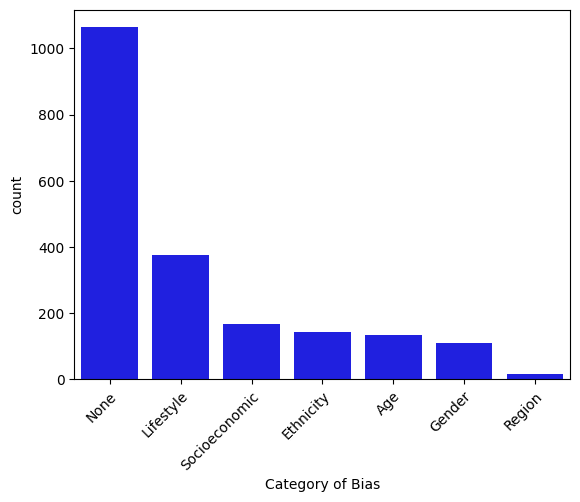

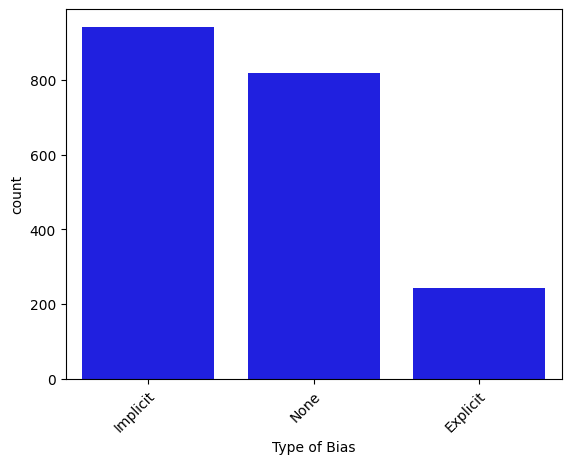

In [12]:
obj_cols = bias_text.select_dtypes(include=object).columns

exclude_sentence = 'Sentences'

filter_obj_cols = obj_cols.difference([exclude_sentence])

for c in filter_obj_cols:
    sns.countplot(bias_text, x=c, color='blue', order=bias_text[c].value_counts().index)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.show()
# end

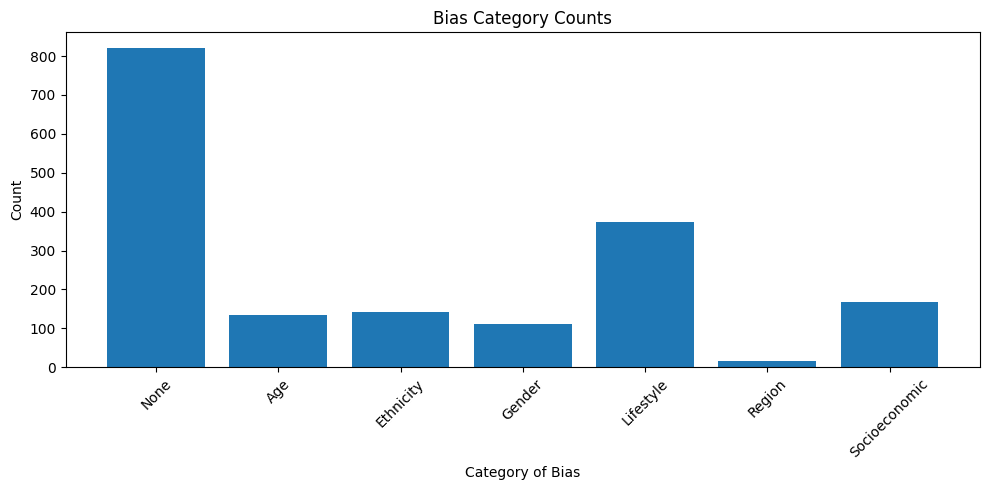

In [13]:
obj_cols = bias_text.select_dtypes(include=object).columns

exclude_sentence = 'Sentences'
filter_obj_cols = obj_cols.difference([exclude_sentence])

df_filtered = bias_text[filter_obj_cols]

# Count occurrences for each (Type of Bias, Category of Bias)
counts = (
    df_filtered.groupby(['Type of Bias', 'Category of Bias'])
               .size()
               .reset_index(name='Count')
)

plt.figure(figsize=(10, 5))
plt.bar(counts['Category of Bias'], counts['Count'])
plt.xlabel('Category of Bias')
plt.ylabel('Count')
plt.title("Bias Category Counts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


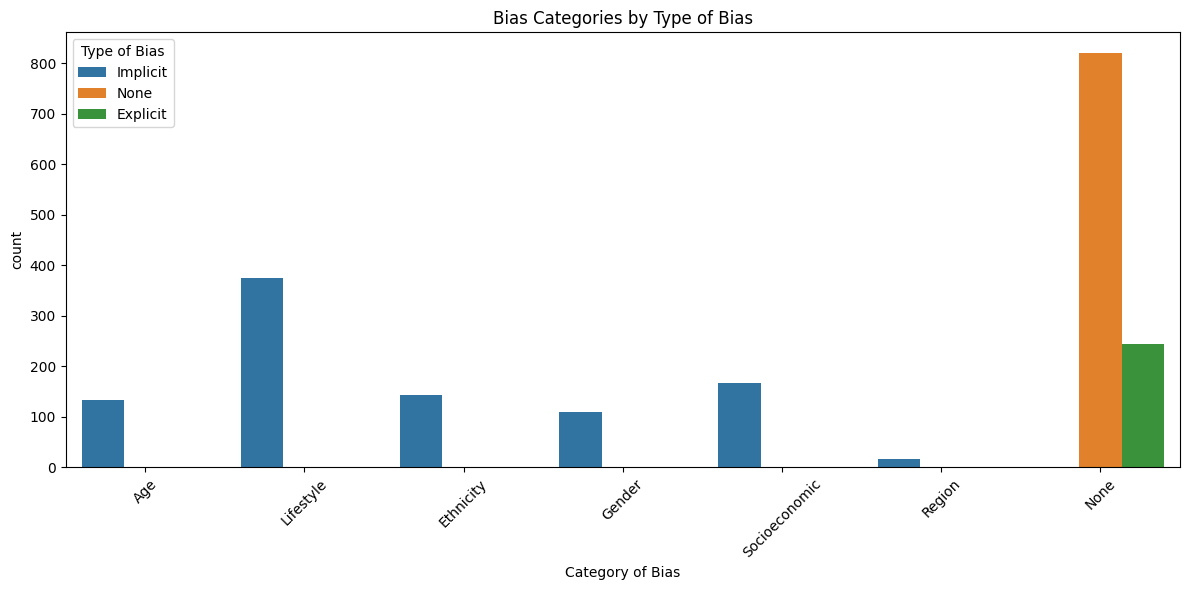

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(data=df_filtered,
              x='Category of Bias',
              hue='Type of Bias')

plt.xticks(rotation=45)
plt.title("Bias Categories by Type of Bias")
plt.tight_layout()
plt.show()

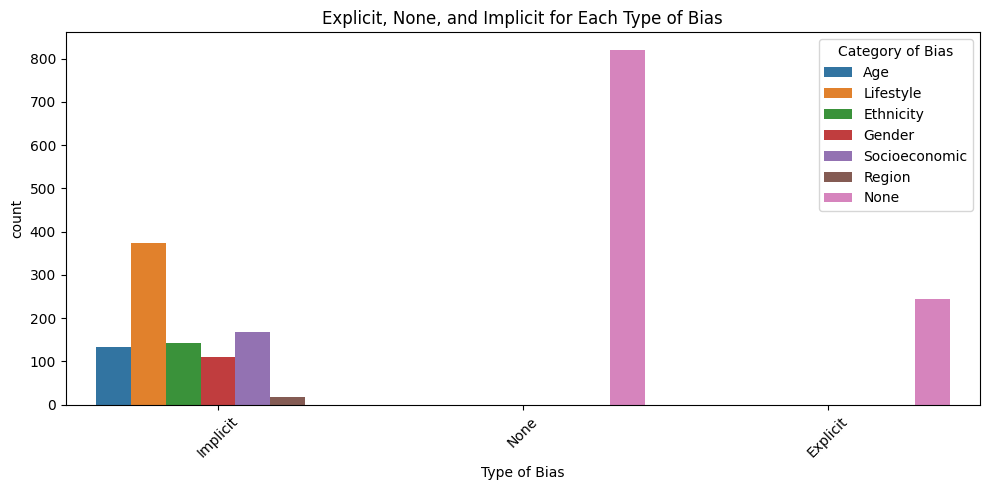

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=bias_text,
    x="Type of Bias",
    hue="Category of Bias",  # Explicit / Implicit
)

plt.xticks(rotation=45)
plt.title("Explicit, None, and Implicit for Each Type of Bias")
plt.tight_layout()
plt.show()

# NLP to analyze text and convert to numerical before Pre-processing. CountVectorizer also does preprocessing such as N-gram, tokenization and other feature engineering

# PRE-PROCESSING

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', ngram_range=(1,2))
X = vectorizer.fit_transform(bias_text['Sentences'])
y = bias_text['Category of Bias']

# MODEL

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    KNeighborsClassifier(n_neighbors=25,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=50),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=70),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression()
               precision    recall  f1-score   support

          Age       0.95      0.70      0.81        27
    Ethnicity       0.94      0.61      0.74        28
       Gender       0.79      0.68      0.73        22
    Lifestyle       0.78      0.84      0.81        75
         None       0.89      0.95      0.92       213
       Region       0.00      0.00      0.00         3
Socioeconomic       0.86      0.94      0.90        34

     accuracy                           0.87       402
    macro avg       0.75      0.67      0.70       402
 weighted avg       0.86      0.87      0.86       402



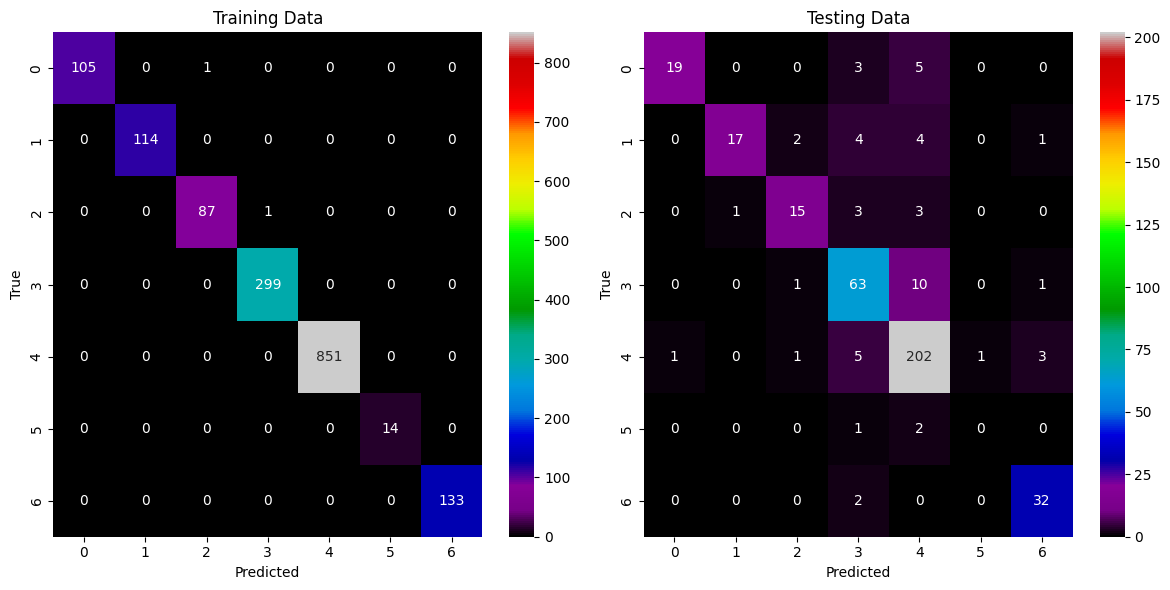

KNeighborsClassifier()
               precision    recall  f1-score   support

          Age       1.00      0.26      0.41        27
    Ethnicity       0.86      0.43      0.57        28
       Gender       0.92      0.50      0.65        22
    Lifestyle       0.82      0.48      0.61        75
         None       0.67      0.97      0.79       213
       Region       0.00      0.00      0.00         3
Socioeconomic       0.93      0.38      0.54        34

     accuracy                           0.71       402
    macro avg       0.74      0.43      0.51       402
 weighted avg       0.76      0.71      0.68       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


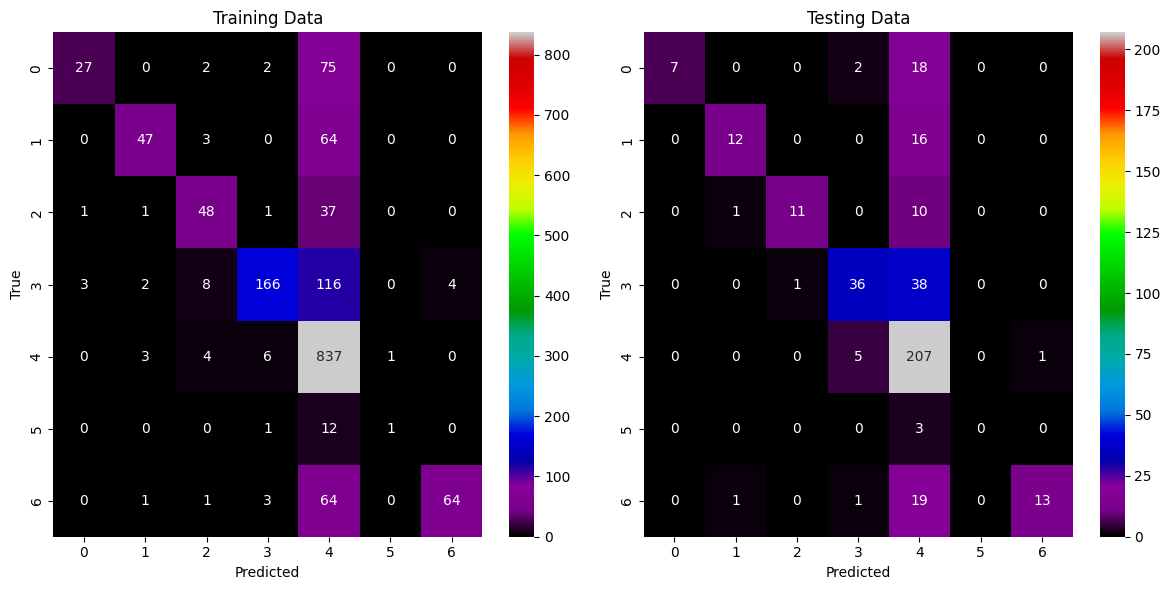

KNeighborsClassifier(n_neighbors=10)
               precision    recall  f1-score   support

          Age       1.00      0.19      0.31        27
    Ethnicity       0.83      0.18      0.29        28
       Gender       0.90      0.41      0.56        22
    Lifestyle       0.90      0.36      0.51        75
         None       0.61      0.99      0.76       213
       Region       0.00      0.00      0.00         3
Socioeconomic       1.00      0.21      0.34        34

     accuracy                           0.66       402
    macro avg       0.75      0.33      0.40       402
 weighted avg       0.75      0.66      0.60       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


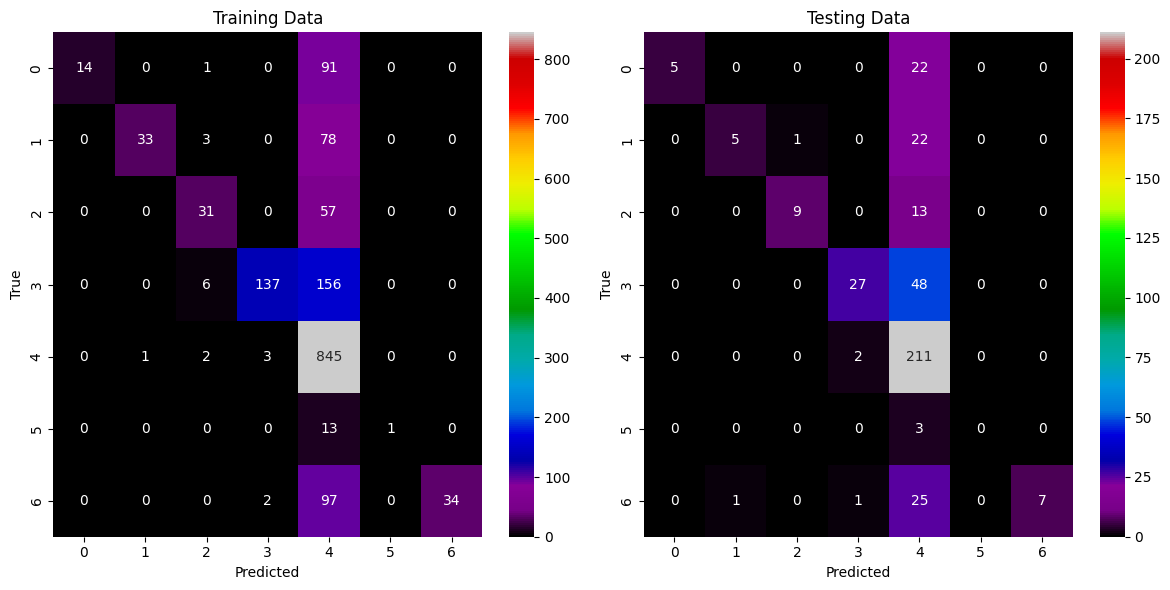

KNeighborsClassifier(n_neighbors=25)
               precision    recall  f1-score   support

          Age       1.00      0.07      0.14        27
    Ethnicity       1.00      0.11      0.19        28
       Gender       1.00      0.18      0.31        22
    Lifestyle       0.85      0.15      0.25        75
         None       0.56      0.99      0.72       213
       Region       0.00      0.00      0.00         3
Socioeconomic       1.00      0.18      0.30        34

     accuracy                           0.59       402
    macro avg       0.77      0.24      0.27       402
 weighted avg       0.73      0.59      0.49       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


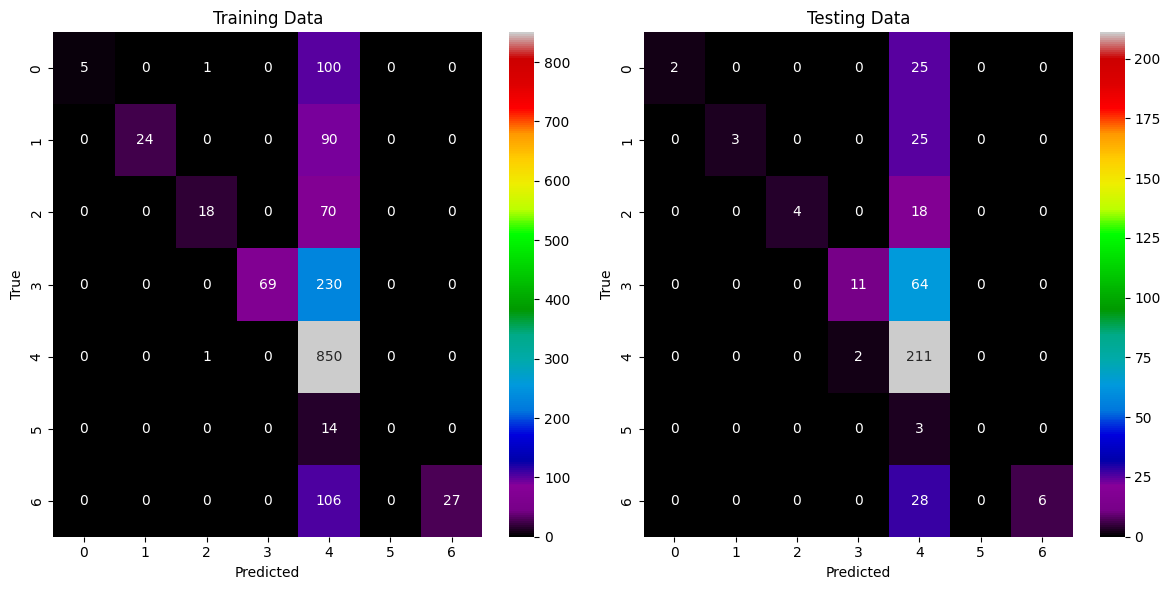

RandomForestClassifier(max_leaf_nodes=30)
               precision    recall  f1-score   support

          Age       0.94      0.56      0.70        27
    Ethnicity       0.93      0.46      0.62        28
       Gender       1.00      0.32      0.48        22
    Lifestyle       0.81      0.57      0.67        75
         None       0.73      0.97      0.83       213
       Region       0.00      0.00      0.00         3
Socioeconomic       0.93      0.79      0.86        34

     accuracy                           0.78       402
    macro avg       0.76      0.53      0.59       402
 weighted avg       0.80      0.78      0.76       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


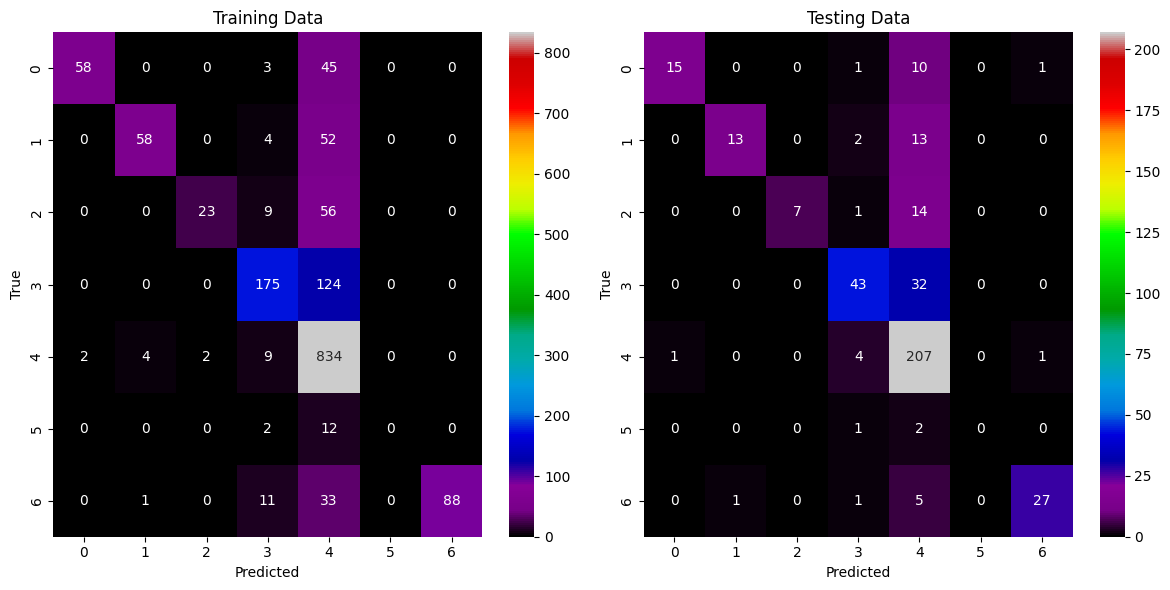

RandomForestClassifier(max_leaf_nodes=50)
               precision    recall  f1-score   support

          Age       0.95      0.67      0.78        27
    Ethnicity       0.93      0.50      0.65        28
       Gender       1.00      0.36      0.53        22
    Lifestyle       0.72      0.68      0.70        75
         None       0.81      0.97      0.88       213
       Region       0.00      0.00      0.00         3
Socioeconomic       0.89      0.91      0.90        34

     accuracy                           0.82       402
    macro avg       0.76      0.58      0.64       402
 weighted avg       0.82      0.82      0.80       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


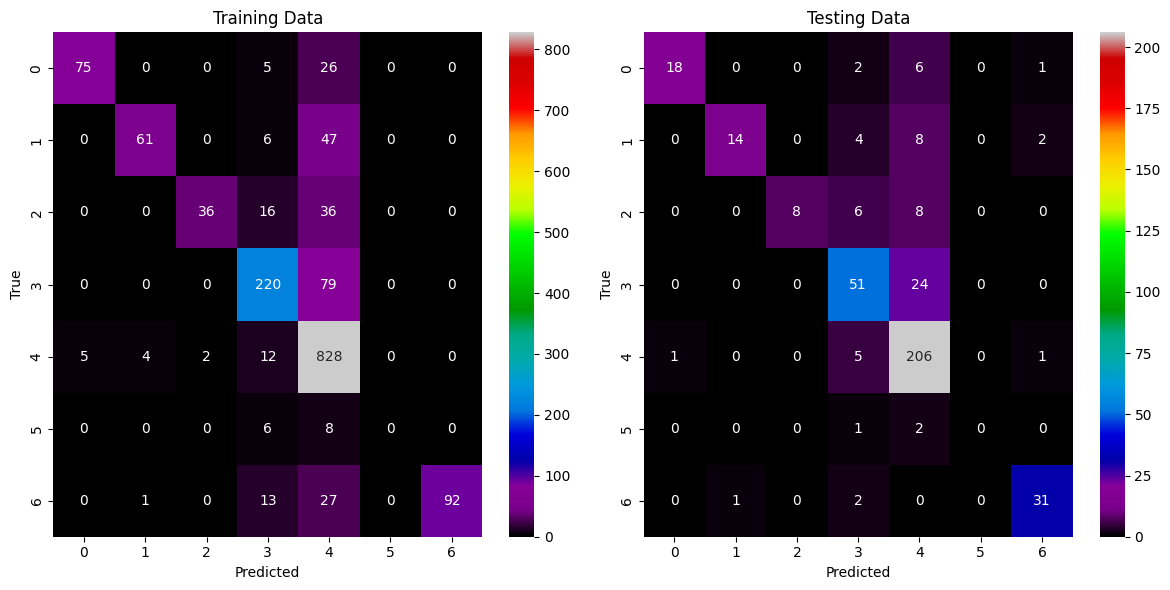

RandomForestClassifier(max_leaf_nodes=70)
               precision    recall  f1-score   support

          Age       0.95      0.70      0.81        27
    Ethnicity       0.93      0.50      0.65        28
       Gender       1.00      0.36      0.53        22
    Lifestyle       0.72      0.69      0.71        75
         None       0.81      0.96      0.88       213
       Region       0.00      0.00      0.00         3
Socioeconomic       0.91      0.91      0.91        34

     accuracy                           0.82       402
    macro avg       0.76      0.59      0.64       402
 weighted avg       0.82      0.82      0.80       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


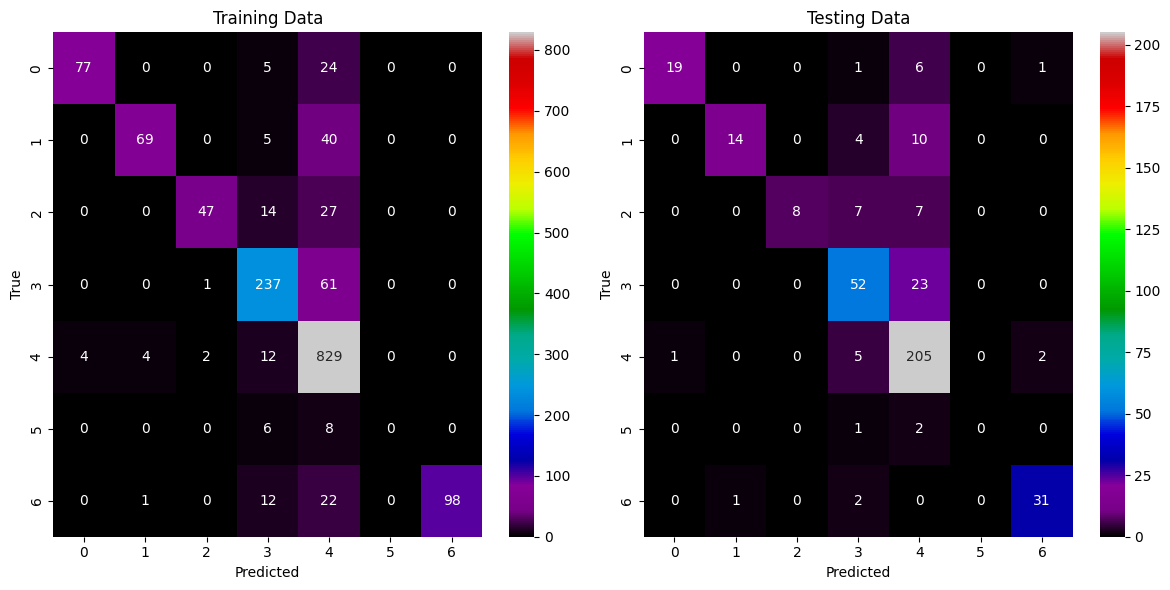

GradientBoostingClassifier(max_leaf_nodes=3)
               precision    recall  f1-score   support

          Age       0.92      0.81      0.86        27
    Ethnicity       0.95      0.71      0.82        28
       Gender       0.82      0.64      0.72        22
    Lifestyle       0.82      0.75      0.78        75
         None       0.87      0.94      0.90       213
       Region       0.50      0.33      0.40         3
Socioeconomic       0.78      0.91      0.84        34

     accuracy                           0.86       402
    macro avg       0.81      0.73      0.76       402
 weighted avg       0.86      0.86      0.85       402



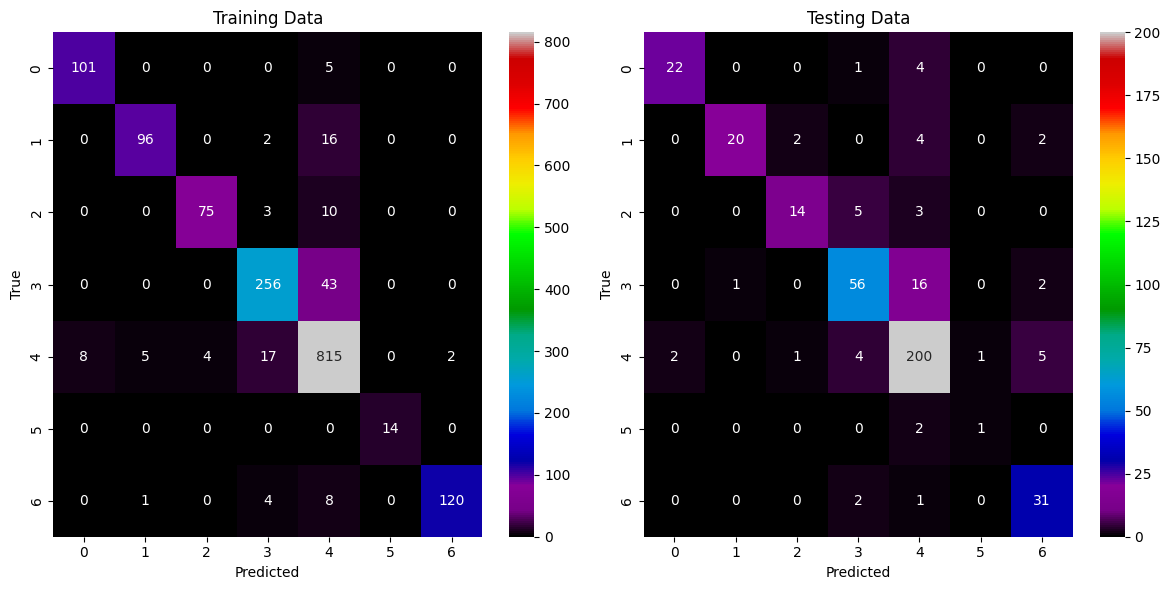

GradientBoostingClassifier(max_leaf_nodes=10)
               precision    recall  f1-score   support

          Age       0.92      0.85      0.88        27
    Ethnicity       0.95      0.71      0.82        28
       Gender       0.88      0.64      0.74        22
    Lifestyle       0.79      0.77      0.78        75
         None       0.88      0.94      0.91       213
       Region       1.00      0.67      0.80         3
Socioeconomic       0.84      0.91      0.87        34

     accuracy                           0.87       402
    macro avg       0.89      0.79      0.83       402
 weighted avg       0.87      0.87      0.87       402



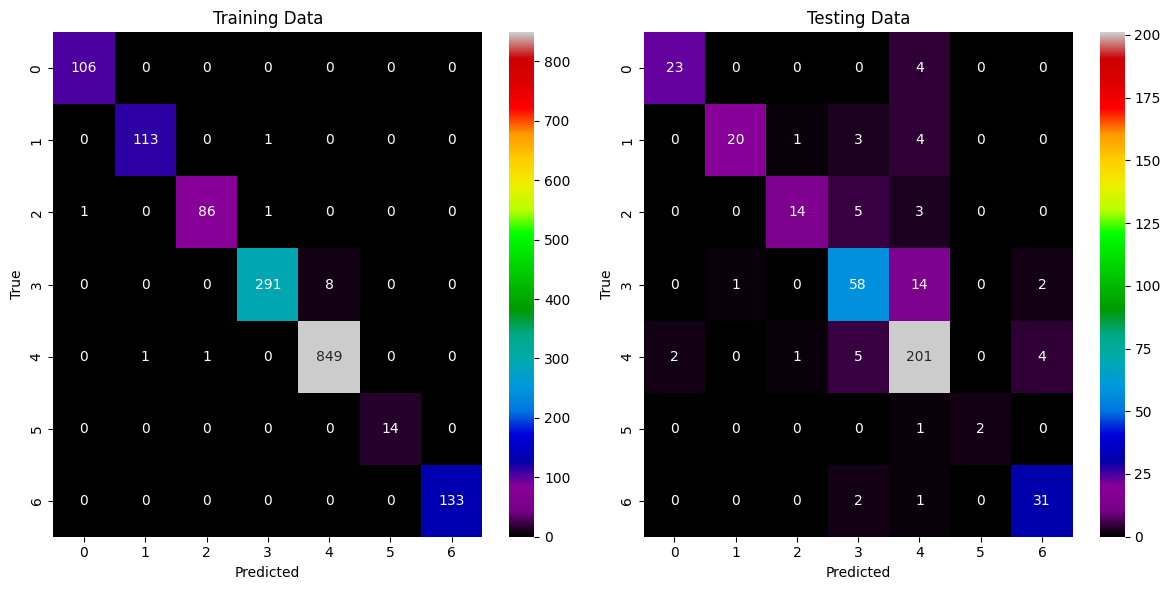

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

# NLP to identify bias in medical text

In [20]:
# Vectorize before running the model

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

feature_names = vectorizer.get_feature_names_out()
# Using coef for logistic regression
logistic_model = models[0]

#Only Logistic Regression provides this attribute (tree-based models have feature importances instead)
coefs = logistic_model.coef_
coefs = logistic_model.coef_[0]  # binary classification → one coef vector

# Top features for Explicit bias (positive coefficients)
top_explicit_idx = np.argsort(coefs)[-20:]
print("Top n-grams for EXPLICIT bias:")
for i in top_explicit_idx:
    print(feature_names[i], coefs[i])

# Top features for Implicit bias (negative coefficients)
top_implicit_idx = np.argsort(coefs)[:20]
print("\nTop n-grams for IMPLICIT bias:")
for i in top_implicit_idx:
    print(feature_names[i], coefs[i])


Top n-grams for EXPLICIT bias:
just older 0.42800903102952303
young healthy 0.4391039117719566
don worry 0.4437621305076477
children don 0.4437621305076477
don think 0.4441270091363484
affect 0.44802088722454103
healthy 0.46479919055518787
medical 0.47124543552198056
based age 0.4864230047778914
sure just 0.5475046168630131
worry 0.5590251369545882
related age 0.6587594448324733
elderly patients 0.9098899170027765
patients 1.0283355217634833
younger patients 1.349881873418955
younger 1.349881873418955
young 1.3743386715719892
older 1.3909030451750537
elderly 1.5831786480021097
age 1.6445944025261778

Top n-grams for IMPLICIT bias:
symptoms -0.42952512590757924
likely -0.32287256281580645
concerns -0.3082979510281065
room -0.29083495181447566
probably -0.2838498693495302
lifestyle -0.26763654176416174
heart issues -0.26094678143867717
sure fully -0.2585333891464977
risk heart -0.2450733365605825
backgrounds -0.23682019695036352
individuals -0.23563858625380718
earlier -0.228050609090646

#TFID removes the effect of common words and highlight discriminative words, while countvectorizer provide raw and frequent words

# TFID and Countvectorizer for Age in the Sentence Medical Text

In [24]:
# COUNT VECTORIZERR
# isolate keywords in age helps explain how bias is expressed linguistically.
from sklearn.feature_extraction.text import CountVectorizer

# First, filter the original DataFrame to include both 'Sentences' and 'Type of Bias'
age_df = bias_text[bias_text['Category of Bias']=='Age']

age_sentences = age_df['Sentences']


vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(age_sentences)
word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())

# Now, 'Type of Bias' can be accessed from age_df
word_counts['Type of Bias'] = age_df['Type of Bias'].values

# Summarize counts by word and bias type
summary = (
    word_counts.groupby('Type of Bias')
    .sum()
    .T  # transpose to make words rows
    .reset_index()
    .rename(columns={'index': 'word'})
)

# Add total count, excluding the 'word' column
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)

# Sort by total count
summary_sorted = summary.sort_values('total_count', ascending=False)

summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
182,heart,91,91
277,patients,77,77
22,age,45,45
317,related,42,42
400,younger,41,41
135,elderly,38,38
122,disease,28,28
235,management,22,22
214,just,20,20
89,condition,19,19


In [23]:
# TFID VECTORIZER
# Filter Age bias sentences
age_df = bias_text[bias_text['Category of Bias']=='Age']
age_sentences = age_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient', 'people','related','based','heart', 'health','tend','disease','conditions', 'condition', 'complaining', 'patients', 'higher', 'just', 'don', 'sure', 'treatment'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(age_sentences)


# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = age_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)

Type of Bias,word,Implicit,total_score
16,age,12.243195,12.243195
243,younger,8.639400,8.639400
79,elderly,8.495546,8.495546
161,older,4.889289,4.889289
142,management,4.815808,4.815808
186,problems,3.813960,3.813960
225,symptoms,3.523329,3.523329
241,young,3.511748,3.511748
45,changes,3.398792,3.398792
30,assume,3.256787,3.256787


# TFID and Countvectorizer for Ethnicity in the Sentence Medical Text

In [22]:
# COUNT VECTORIZER
ethnicity_df = bias_text[bias_text['Category of Bias']=='Ethnicity']
ethnicity_sentences = ethnicity_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(ethnicity_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = ethnicity_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary[['Implicit']].sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
100,cultural,62,124
254,patients,54,108
73,certain,45,90
61,backgrounds,44,88
175,heart,43,86
253,patient,36,72
311,room,34,68
120,disease,33,66
138,ethnic,31,62
63,beliefs,31,62


In [25]:
# TFID VECTORIZER
# Filter Ethnicity bias sentences
ethnicity_df = bias_text[bias_text['Category of Bias'] == 'Ethnicity']
ethnicitiy_sentences = ethnicity_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient','room','patient room','heart','heart disease','disease','certain', 'did', 'healthcare', 'patients', 'people', 'don'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(ethnicity_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = ethnicity_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)


Type of Bias,word,Implicit,total_score
82,cultural,9.339591,9.339591
42,backgrounds,8.208190,8.208190
119,ethnic,6.249475,6.249475
53,beliefs,5.952538,5.952538
121,ethnic backgrounds,5.472709,5.472709
34,background,5.156498,5.156498
276,treatment,5.048496,5.048496
102,different,4.984021,4.984021
212,practices,4.645507,4.645507
84,cultural backgrounds,4.596777,4.596777


# TFID and Countvectorizer for None in the Sentence Medical Text

In [26]:
# COUNT VECTORIZER
none_df = bias_text[bias_text['Category of Bias']=='None']
none_sentences = none_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(none_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = none_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary[['None']].sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Explicit,None,total_count
568,heart,208,167,542
561,health,36,203,442
692,let,29,197,423
869,patient,20,184,388
603,important,0,174,348
713,ll,1,123,247
247,concerns,20,112,244
725,make,0,116,232
1200,sure,3,100,203
366,disease,83,60,203


In [27]:
# TFID VECTORIZER
# Filter None bias sentences in medical text
none_df = bias_text[bias_text['Category of Bias'] == 'None']
none_sentences = none_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient', 'symptoms', 'reported', 'heart', 'health', 'don', 'room', 'll', 'll make', 'let', 'think', 'sure', 'medication', 'likely', 'risk', 'based', 'earlier', 'chest', 'probably', 'common', 'complaining', 'pain', 'just', 'today','saw','assume','provide','higher', 'did', 'mentioned', 'patients', 'people', 'presented', 'disease', 'concerns', 'related'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(none_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = none_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['make'] not in stop_words.
  warnings.warn(


Type of Bias,word,Explicit,None,total_score
839,important,0.000000,26.301774,26.301774
1042,make,0.000000,23.717385,23.717385
950,know,0.000000,20.553254,20.553254
223,care,1.410799,16.591817,18.002617
1701,treatment,0.763940,16.384223,17.148164
1141,necessary,0.236419,15.842347,16.078766
753,healthcare,0.319591,15.321701,15.641292
1628,support,0.520336,14.142224,14.662559
995,lifestyle,7.584640,6.924696,14.509335
1327,problems,12.014838,2.304332,14.319170


# TFID and Countvectorizer for Socioeconomic in the Sentence Medical Text

In [28]:
# COUNT VECTORIZER
socioeconomic_df = bias_text[bias_text['Category of Bias']=='Socioeconomic']
socioeconomic_sentences = socioeconomic_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(socioeconomic_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = socioeconomic_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary[['Implicit']].sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
177,heart,105,210
179,higher,58,116
322,related,55,110
217,levels,52,104
196,individuals,44,88
15,access,43,86
91,condition,39,78
120,disease,37,74
52,based,35,70
43,assume,35,70


In [29]:
# TFID VECTORIZER
# Filter Socioeconomic bias sentences
socioeconomic_df = bias_text[bias_text['Category of Bias'] == 'Socioeconomic']
socioeconomic_sentences = socioeconomic_df['Sentences']


# Combine built-in + custom stopwords
extra_stopwords = {'patient','heart', 'likely', 'risk', 'based', 'treatment', 'sure', 'levels', 'health','cardiac','assume','provide','higher', 'did', 'related', 'patients', 'people', 'condition', 'disease', 'concerns', 'related'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(socioeconomic_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = socioeconomic_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)


Type of Bias,word,Implicit,total_score
150,individuals,7.776334,7.776334
2,access,7.490565,7.490565
209,occupation,7.248576,7.248576
145,income,7.110930,7.110930
186,lower,6.893392,6.893392
290,socioeconomic,6.191962,6.191962
303,stress,5.272794,5.272794
104,exposure,5.177418,5.177418
87,educational,5.052157,5.052157
158,job,4.923152,4.923152


# TFID and Countvectorizer for Lifestyle in the Sentence Medical Text

In [30]:
# COUNT VECTORIZER
lifestyle_df = bias_text[bias_text['Category of Bias']=='Lifestyle']
lifestyle_sentences = lifestyle_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(lifestyle_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = lifestyle_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
476,patient,181,362
370,just,129,258
318,heart,109,218
325,history,104,208
568,room,95,190
548,related,89,178
389,likely,71,142
157,condition,67,134
223,earlier,56,112
471,pain,55,110


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TFID VECTORIZER
# Filter lifestyle bias sentences
lifestyle_df = bias_text[bias_text['Category of Bias'] == 'Lifestyle']
lifestyle_sentences = lifestyle_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient','heart', 'health', 'don', 'room', 'think', 'sure', 'medication', 'likely', 'risk', 'based', 'earlier', 'chest', 'probably', 'common', 'complaining', 'pain', 'just', 'today','saw','assume','provide','higher', 'did', 'mentioned', 'patients', 'people', 'presented', 'disease', 'concerns', 'related'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(lifestyle_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = lifestyle_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)


Type of Bias,word,Implicit,total_score
267,history,17.515572,17.515572
125,condition,15.738308,15.738308
564,symptoms,10.132864,10.132864
342,lifestyle,9.041761,9.041761
321,issues,8.742320,8.742320
214,family,8.625504,8.625504
215,family history,8.420118,8.420118
380,mental,8.399282,8.399282
456,problems,7.210945,7.210945
216,fatigue,6.366170,6.366170


# TFID and Countvectorizer for Gender in the Sentence Medical Text

In [32]:
# COUNT VECTORIZER
gender_df = bias_text[bias_text['Category of Bias']=='Gender']
gender_sentences = gender_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(gender_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = gender_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
116,just,51,102
177,reported,29,58
212,symptoms,29,58
156,patient,29,58
70,earlier,29,58
154,pain,28,56
189,saw,27,54
167,probably,26,52
98,heart,24,48
230,women,23,46


In [33]:
# TFID VECTORIZER
# Filter Gender bias sentences
gender_df = bias_text[bias_text['Category of Bias'] == 'Gender']
gender_sentences = gender_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient', 'symptoms', 'reported', 'heart', 'health', 'don', 'room', 'think', 'sure', 'medication', 'likely', 'risk', 'based', 'earlier', 'chest', 'probably', 'common', 'complaining', 'pain', 'just', 'today','saw','assume','provide','higher', 'did', 'mentioned', 'patients', 'people', 'presented', 'disease', 'concerns', 'related'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(gender_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = gender_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)


Type of Bias,word,Implicit,total_score
159,women,7.631260,7.631260
62,gender,5.807256,5.807256
106,men,5.201421,5.201421
11,assumed,4.505574,4.505574
55,emotional,4.491728,4.491728
117,pregnant,4.073750,4.073750
150,trimester,3.848788,3.848788
151,trimester assumed,3.848788,3.848788
26,care,3.847010,3.847010
15,attention,3.540241,3.540241


# TFID and Countvectorizer for Region in the Sentence Medical Text

In [34]:
# COUNT VECTORIZER
region_df = bias_text[bias_text['Category of Bias']=='Region']
region_sentences = region_df['Sentences']

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(region_sentences)

word_counts = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
word_counts['Type of Bias'] = region_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit)
summary = (word_counts.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total word frequency and sort descending
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)

# Exclude the 'word' column from the sum calculation
summary['total_count'] = summary.drop(columns=['word']).sum(axis=1)
summary_sorted = summary.sort_values('total_count', ascending=False)

# Display the top 20 words
summary_sorted.head(20)

Type of Bias,word,Implicit,total_count
55,people,7,14
36,heart,7,14
69,rural,7,14
46,live,5,10
5,areas,5,10
67,risk,5,10
38,higher,4,8
1,access,4,8
11,care,3,6
4,area,3,6


In [35]:
# TFID VECTORIZER
# Filter Region bias sentences
region_df = bias_text[bias_text['Category of Bias'] == 'Region']
region_sentences = region_df['Sentences']

# Combine built-in + custom stopwords
extra_stopwords = {'patient', 'symptoms', 'reported', 'heart', 'health', 'don', 'room', 'think', 'sure', 'medication', 'likely', 'risk', 'based', 'earlier', 'chest', 'probably', 'common', 'complaining', 'pain', 'just', 'today','saw','assume','provide','higher', 'did', 'mentioned', 'patients', 'people', 'presented', 'disease', 'concerns', 'related'}
combined_stopwords = list(text.ENGLISH_STOP_WORDS.union(extra_stopwords))

# TF-IDF vectorizer instead of CountVectorizer
vec = TfidfVectorizer(stop_words=combined_stopwords, ngram_range=(1,2),
    min_df=2,       # appear in at least 2 sentences
    max_df=0.8      # appear in less than 80% of sentences
)
X_tfidf = vec.fit_transform(region_sentences)

# TF-IDF matrix → DataFrame, add Type of Bias
word_scores = pd.DataFrame(X_tfidf.toarray(), columns=vec.get_feature_names_out())
word_scores['Type of Bias'] = region_df['Type of Bias'].values

# Group by Type of Bias (Implicit / Explicit) and sum TF-IDF scores
summary = (word_scores.groupby('Type of Bias').sum().T.reset_index().rename(columns={'index': 'word'}))

# Add total TF-IDF score across both bias types and sort
summary['total_score'] = summary.drop(columns=['word']).sum(axis=1)

summary_sorted = summary.sort_values('total_score', ascending=False)

# Show top 20 words by TF-IDF importance
summary_sorted.head(20)

Type of Bias,word,Implicit,total_score
11,live,3.409861,3.409861
16,rural,2.591733,2.591733
2,areas,2.547523,2.547523
14,problems,2.068459,2.068459
18,rural areas,2.000306,2.000306
12,living,1.800869,1.800869
0,access,1.435169,1.435169
1,area,1.387742,1.387742
17,rural area,1.387742,1.387742
4,countries,1.304239,1.304239


In [ ]:
#! pip install gensim

In [36]:
! pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00


In [37]:
! pip install scispacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.

In [ ]:
#!pip install --upgrade pip
#!pip install -U spacy scispacy
#!pip install https://s3.amazonaws.com/ai2-s2-scispacy/releases/v0.5.0/en_core_sci_sm-0.5.0.tar.gz



# SENTIMENT ANALYSIS

In [38]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment analysis on sentences
bias_text["sentiment_score"] = bias_text["Sentences"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

# Classify as positive / neutral / negative
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

bias_text["sentiment_label"] = bias_text["sentiment_score"].apply(label_sentiment)

# Show some results
bias_text[["Sentences", "sentiment_score", "sentiment_label"]]

,Sentences,sentiment_score,sentiment_label
0,Heart problems aren't as serious for younger p...,0.4063,Positive
1,Busy professionals should be more cautious abo...,0.5434,Positive
2,It's surprising to see a fit person suffer fro...,0.6486,Positive
3,People with high-stress jobs tend to have weak...,0.3400,Positive
4,A healthy diet is less important for young peo...,0.8130,Positive
...,...,...,...
2002,Women tend to be more emotional than men.,0.2247,Positive
2003,People from certain ethnic backgrounds are mor...,-0.0935,Negative
2004,People from rural areas are less educated.,0.0000,Neutral
2005,Older individuals are slower in grasping new c...,0.0000,Neutral


In [ ]:
#! pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
bias_label = bias_text["sentiment_label"].count()
bias_label

np.int64(2007)

# Named Entity Recognition

In [ ]:
'''import spacy

nlp = spacy.load("en_core_sci_sm")  # biomedical NER model


def extract_ents(bias_text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents]

bias_text["entities"] = bias_text["Sentences"].apply(extract_ents)

print(bias_text[["Sentences", "entities"]].head(10))'''


# Bias Analysis with Visualization

In [ ]:
age_df = bias_text[bias_text["Category of Bias"] == "Age"]
# explode entities, count DISEASE mentions, etc.
age_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
0,Heart problems aren't as serious for younger p...,Implicit,Age,0.4063,Positive
4,A healthy diet is less important for young peo...,Implicit,Age,0.8130,Positive
9,Middle-aged men are the primary demographic fo...,Implicit,Age,0.6369,Positive
51,Heart failure is mainly a problem for the elde...,Implicit,Age,-0.2023,Negative
63,Children don't have to worry about heart probl...,Implicit,Age,0.6002,Positive
...,...,...,...,...,...
1439,I had a patient complaining of dizziness. Turn...,Implicit,Age,-0.7430,Negative
1457,I had a patient complaining of back pain. Turn...,Implicit,Age,-0.8126,Negative
1475,I had a patient complaining of joint pain. Tur...,Implicit,Age,-0.8126,Negative
1539,Did you assess the patient in Room 211? They'r...,Implicit,Age,0.0000,Neutral


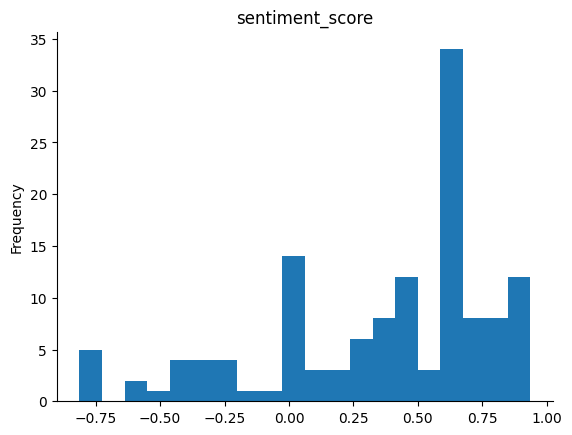

In [ ]:
from matplotlib import pyplot as plt
age_df['sentiment_score'].plot(kind='hist', bins=20, title='sentiment_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

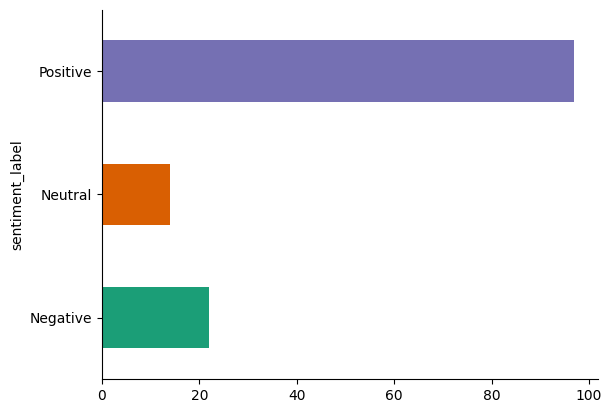

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
age_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

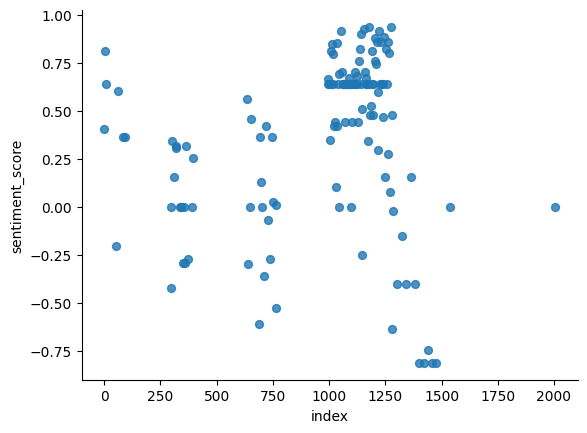

In [ ]:
age_df = age_df.reset_index()
age_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [39]:
ethnicity_df = bias_text[bias_text["Category of Bias"] == "Ethnicity"]
# explode entities, count DISEASE mentions, etc.
ethnicity_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
6,People from certain ethnic backgrounds need to...,Implicit,Ethnicity,0.7845,Positive
56,African Americans have a higher risk of heart ...,Implicit,Ethnicity,-0.0516,Negative
70,Asians are less likely to experience heart fai...,Implicit,Ethnicity,0.2263,Positive
84,Heart disease is more common in certain races.,Implicit,Ethnicity,0.7624,Positive
324,"I don't think he's really in that much pain, h...",Implicit,Ethnicity,-0.5106,Negative
...,...,...,...,...,...
1519,The patient in Room 405 is from an immigrant b...,Implicit,Ethnicity,0.5994,Positive
1536,The patient in Room 406 is from an immigrant b...,Implicit,Ethnicity,0.5994,Positive
1545,Did you see the patient in Room 416? They're f...,Implicit,Ethnicity,0.0000,Neutral
1554,The patient in Room 407 is from an immigrant b...,Implicit,Ethnicity,0.0000,Neutral


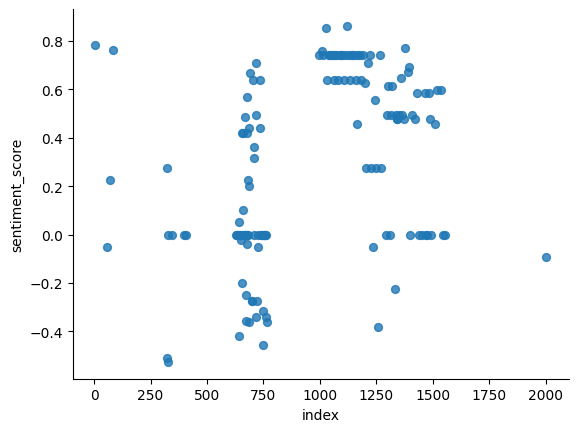

In [ ]:
ethnicity_df = ethnicity_df.reset_index()
ethnicity_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

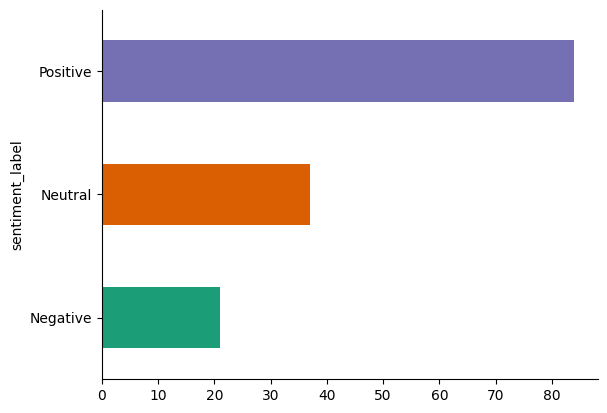

In [ ]:
ethnicity_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
none_df = bias_text[bias_text["Category of Bias"] == "None"]
# explode entities, count DISEASE mentions, etc.
none_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
100,Regular exercise can reduce the risk of heart ...,None,None,0.4767,Positive
101,Eating a balanced diet is essential for mainta...,None,None,0.7964,Positive
102,Smoking is a significant risk factor for heart...,None,None,0.5994,Positive
103,High blood pressure can contribute to the deve...,None,None,0.0772,Positive
104,Reducing stress can help improve heart health.,None,None,0.7906,Positive
...,...,...,...,...,...
1997,"Engaging in stress-reducing activities, such a...",None,None,0.8402,Positive
1998,"Replacing saturated fats with healthier fats, ...",None,None,0.8979,Positive
1999,Avoiding or quitting smoking reduces the risk ...,None,None,-0.1779,Negative
2000,Monitoring and managing your weight through a ...,None,None,0.7717,Positive


In [ ]:
gender_df = bias_text[bias_text["Category of Bias"] == "Gender"]
# explode entities, count DISEASE mentions, etc.
gender_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
7,Women's heart symptoms are often more subtle t...,Implicit,Gender,0.6369,Positive
50,Men are more likely to suffer from heart disea...,Implicit,Gender,0.1119,Positive
57,Women don't need to worry about heart disease ...,Implicit,Gender,0.7654,Positive
73,Women's heart problems are often just stress-r...,Implicit,Gender,0.3612,Positive
76,Heart attacks are a man's problem.,Implicit,Gender,-0.1027,Negative
...,...,...,...,...,...
1533,I saw a pregnant patient earlier who reported ...,Implicit,Gender,0.0000,Neutral
1543,I saw a patient earlier who reported chest pai...,Implicit,Gender,0.4588,Positive
1551,I saw a pregnant patient earlier who reported ...,Implicit,Gender,-0.6059,Negative
1561,I saw a patient earlier who reported chest pai...,Implicit,Gender,0.4404,Positive


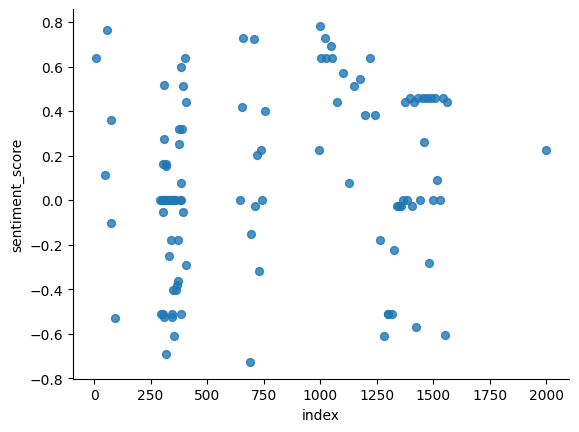

In [ ]:
gender_df = gender_df.reset_index()
gender_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

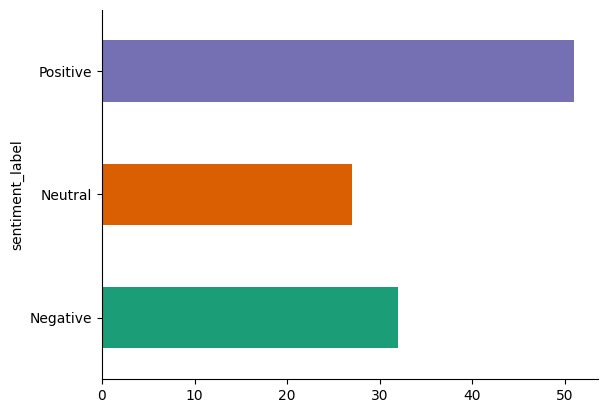

In [ ]:
gender_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [40]:
lifestyle_df = bias_text[bias_text["Category of Bias"] == "Lifestyle"]
# explode entities, count DISEASE mentions, etc.
lifestyle_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
1,Busy professionals should be more cautious abo...,Implicit,Lifestyle,0.5434,Positive
2,It's surprising to see a fit person suffer fro...,Implicit,Lifestyle,0.6486,Positive
3,People with high-stress jobs tend to have weak...,Implicit,Lifestyle,0.3400,Positive
5,Heart issues are more common in those who don'...,Implicit,Lifestyle,0.6369,Positive
11,Heart issues don't typically affect those who ...,Implicit,Lifestyle,0.6369,Positive
...,...,...,...,...,...
1556,The patient in Room 613 is an athlete complain...,Implicit,Lifestyle,-0.7845,Negative
1558,I had a patient earlier who presented with che...,Implicit,Lifestyle,0.2263,Positive
1559,The patient in Room 406 has a history of nonco...,Implicit,Lifestyle,0.4019,Positive
1560,Did you hear about the patient in Room 514? Th...,Implicit,Lifestyle,-0.4019,Negative


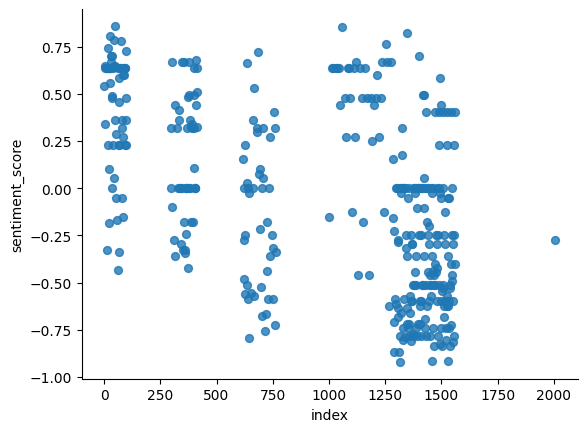

In [ ]:
lifestyle_df = lifestyle_df.reset_index()
lifestyle_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

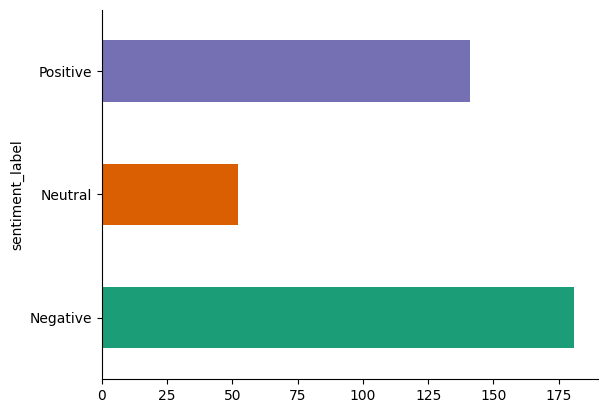

In [ ]:
lifestyle_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
socioeconomic_df = bias_text[bias_text["Category of Bias"] == "Socioeconomic"]
# explode entities, count DISEASE mentions, etc.
socioeconomic_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
8,Heart problems aren't a big concern for the up...,Implicit,Socioeconomic,0.3612,Positive
12,Lower-income populations tend to have more hea...,Implicit,Socioeconomic,0.6697,Positive
18,Heart problems are more common among those who...,Implicit,Socioeconomic,0.3607,Positive
31,Heart disease is less common among people who ...,Implicit,Socioeconomic,0.8176,Positive
32,Heart problems are more common among those who...,Implicit,Socioeconomic,0.5859,Positive
...,...,...,...,...,...
1501,The patient in Room 404 is from an immigrant b...,Implicit,Socioeconomic,0.5994,Positive
1504,Did you assess the patient in Room 209? They'r...,Implicit,Socioeconomic,0.0000,Neutral
1522,Did you assess the patient in Room 210? They'r...,Implicit,Socioeconomic,0.0000,Neutral
1527,Did you see the patient in Room 415? They're f...,Implicit,Socioeconomic,0.0000,Neutral


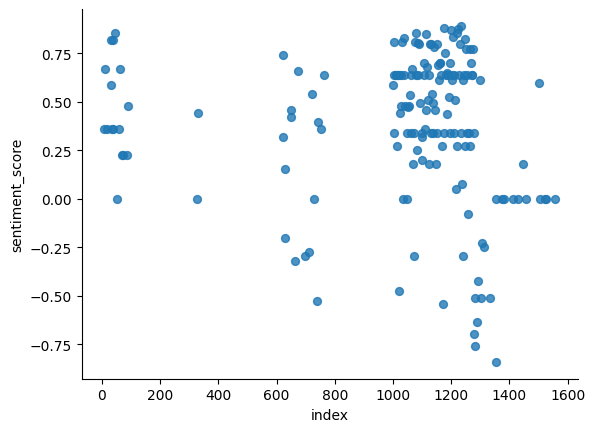

In [ ]:
socioeconomic_df = socioeconomic_df.reset_index()
socioeconomic_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

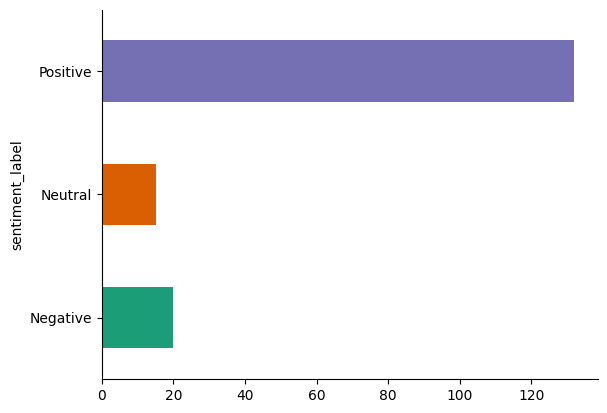

In [ ]:
socioeconomic_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
region_df = bias_text[bias_text["Category of Bias"] == "Region"]
# explode entities, count DISEASE mentions, etc.
region_df

,Sentences,Type of Bias,Category of Bias,sentiment_score,sentiment_label
10,People who live in colder climates have a high...,Implicit,Region,0.1027,Positive
14,Heart problems are less common in countries wi...,Implicit,Region,0.3612,Positive
22,Heart disease is more prevalent in countries w...,Implicit,Region,0.6369,Positive
25,People who live in urban areas are at a higher...,Implicit,Region,0.4767,Positive
45,People who live in neighborhoods with limited ...,Implicit,Region,0.2960,Positive
54,Individuals living in rural areas have better ...,Implicit,Region,0.7964,Positive
72,People who live in cities have a higher risk o...,Implicit,Region,0.1027,Positive
618,"I'm sorry, but we don't have any translators a...",Implicit,Region,-0.0387,Neutral
636,You're from that neighborhood? I've heard it's...,Implicit,Region,-0.5216,Negative
666,You must be used to living in crowded conditio...,Implicit,Region,0.0000,Neutral


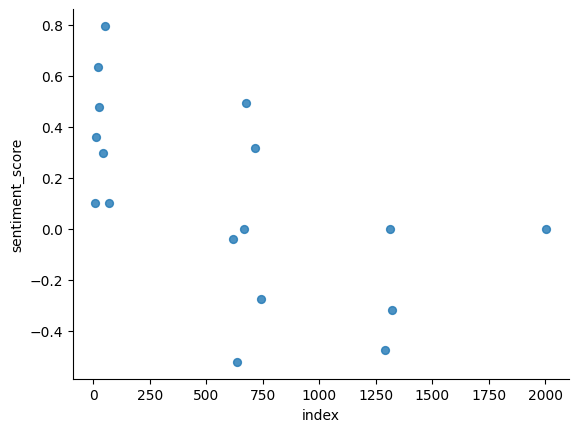

In [ ]:
region_df = region_df.reset_index()
region_df.plot(kind='scatter', x='index', y='sentiment_score', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

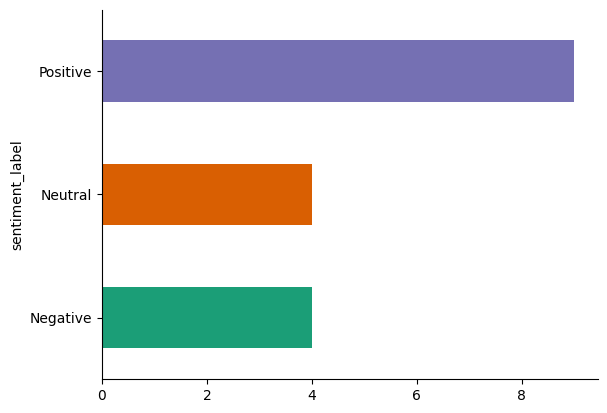

In [ ]:
region_df.groupby('sentiment_label').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)